# 🛒 EDA Notebook — Dunnhumby "The Complete Journey"
**Project**: Customer Lifetime Value & Market Basket Analysis  
**Team**: DSEB65A — Group 6 | **Branch**: phong

---
## Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis)
3. [Cohort Analysis](#3-cohort-analysis)
4. [Market Basket Analysis](#4-market-basket-analysis)


## 1. Setup & Data Loading

In [1]:
import sys, os, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import yaml

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

# ── Paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()
# Handle both: notebook opened from notebooks/ OR from project root
if (NOTEBOOK_DIR / "configs").exists():
    PROJECT_ROOT = NOTEBOOK_DIR          # CWD is already project root
else:
    PROJECT_ROOT = NOTEBOOK_DIR.parent   # CWD is notebooks/

CONFIG_PATH  = PROJECT_ROOT / "configs" / "config.yaml"
RAW_DIR      = PROJECT_ROOT / "data" / "raw"
REPORTS_DIR  = PROJECT_ROOT / "reports" / "figures"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Change CWD to project root so all relative paths in config.yaml resolve correctly
os.chdir(str(PROJECT_ROOT))
print(f"Working dir  : {os.getcwd()}")

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

print(f"Project root : {PROJECT_ROOT}")
print(f"Raw data dir : {RAW_DIR}")
print(f"Config loaded: {config['project']['name']} v{config['project']['version']}")


Working dir  : D:\hoc ki 6\thay long\data_driven_marketing_project
Project root : D:\hoc ki 6\thay long\data_driven_marketing_project
Raw data dir : D:\hoc ki 6\thay long\data_driven_marketing_project\data\raw
Config loaded: clv_dunnhumby v1.0.0


In [2]:
# ── Add src to path so we can reuse existing modules ──────────────────────────
sys.path.insert(0, str(PROJECT_ROOT))
from src.data.data_loader import DunnhumbyDataLoader
from src.features.rfm_builder import RFMBuilder
from src.features.time_splitter import TimeSplitter

loader = DunnhumbyDataLoader(config)

txn  = loader.load_transactions()
demo = loader.load_demographics()
prod = loader.load_products()

print(f"\nTransactions : {txn.shape}")
print(f"Demographics : {demo.shape}")
print(f"Products     : {prod.shape}")


2026-04-25 20:11:02.443 | INFO     | src.data.data_loader:load_transactions:147 - Loading transaction_data from data/raw/transaction_data.csv ...
2026-04-25 20:11:04.472 | INFO     | src.data.data_loader:load_transactions:149 -   → Loaded 2,595,732 rows × 12 cols (106.4 MB)
2026-04-25 20:11:04.472 | INFO     | src.data.data_loader:load_demographics:189 - Loading hh_demographic from data/raw/hh_demographic.csv ...
2026-04-25 20:11:04.506 | INFO     | src.data.data_loader:load_demographics:202 -   → Loaded 801 rows × 8 cols (12.8 KB)
2026-04-25 20:11:04.507 | INFO     | src.data.data_loader:load_products:353 - Loading product from data/raw/product.csv ...
2026-04-25 20:11:04.649 | INFO     | src.data.data_loader:load_products:361 -   → Loaded 92,353 rows



Transactions : (2595732, 12)
Demographics : (801, 8)
Products     : (92353, 7)


In [3]:
# ── Merge product info into transactions (for basket analysis later) ───────────
prod_cols = ["PRODUCT_ID", "DEPARTMENT", "COMMODITY_DESC", "BRAND"]
txn = txn.merge(prod[prod_cols], on="PRODUCT_ID", how="left")

# ── Basic cleaning (reuse data_prep logic) ────────────────────────────────────
before = len(txn)
txn = txn[(txn["QUANTITY"] > 0) & (txn["SALES_VALUE"] > 0)].copy()
print(f"Removed {before - len(txn):,} rows with QUANTITY/SALES_VALUE <= 0")

# Net sales
txn["Net_Sales"] = (txn["SALES_VALUE"] + txn["RETAIL_DISC"]
                    + txn["COUPON_DISC"] + txn["COUPON_MATCH_DISC"]).clip(lower=0)

print(f"\nClean transactions: {len(txn):,} rows")
print(f"Households        : {txn['household_key'].nunique():,}")
print(f"Baskets           : {txn['BASKET_ID'].nunique():,}")
print(f"Products          : {txn['PRODUCT_ID'].nunique():,}")
print(f"Week range        : {txn['WEEK_NO'].min()} – {txn['WEEK_NO'].max()}")


Removed 18,944 rows with QUANTITY/SALES_VALUE <= 0

Clean transactions: 2,576,788 rows
Households        : 2,500
Baskets           : 275,516
Products          : 91,905
Week range        : 1 – 102


## 2. Exploratory Data Analysis

### 2.1 Transaction Volume Over Time

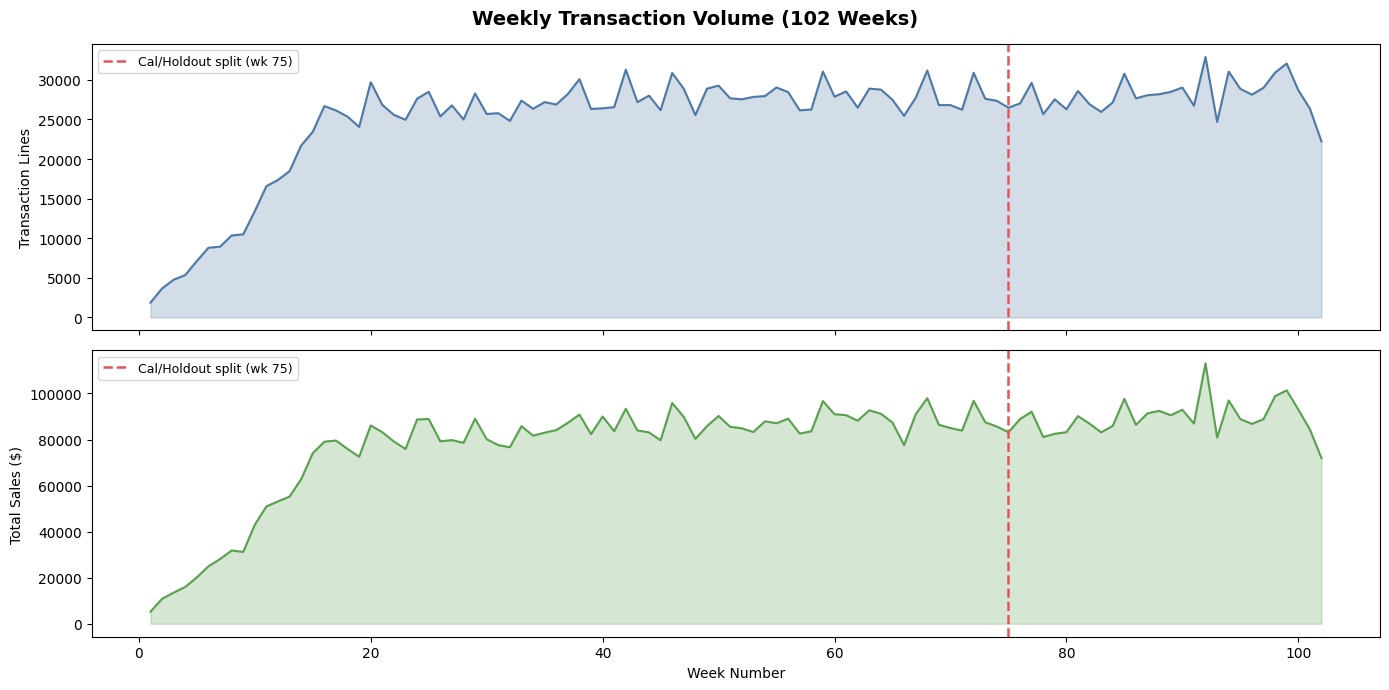

Saved → eda_01_weekly_volume.png


In [4]:
weekly = (txn.groupby("WEEK_NO")
            .agg(n_txn=("BASKET_ID","count"),
                 total_sales=("SALES_VALUE","sum"),
                 n_hh=("household_key","nunique"))
            .reset_index())

CAL_END = config["splitting"]["calibration_end_week"]

fig, axes = plt.subplots(2, 1, figsize=(14,7), sharex=True)
fig.suptitle("Weekly Transaction Volume (102 Weeks)", fontsize=14, fontweight="bold")

for ax, col, label, color in [
    (axes[0], "n_txn",       "Transaction Lines", "#4E79A7"),
    (axes[1], "total_sales", "Total Sales ($)",   "#59A14F"),
]:
    ax.fill_between(weekly["WEEK_NO"], weekly[col], alpha=0.25, color=color)
    ax.plot(weekly["WEEK_NO"], weekly[col], color=color, lw=1.5)
    ax.axvline(CAL_END, color="#E15759", ls="--", lw=1.8, label=f"Cal/Holdout split (wk {CAL_END})")
    ax.set_ylabel(label); ax.legend(fontsize=9)

axes[1].set_xlabel("Week Number")
plt.tight_layout(); plt.savefig(REPORTS_DIR/"eda_01_weekly_volume.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved → eda_01_weekly_volume.png")


### 2.2 Sales Value Distribution

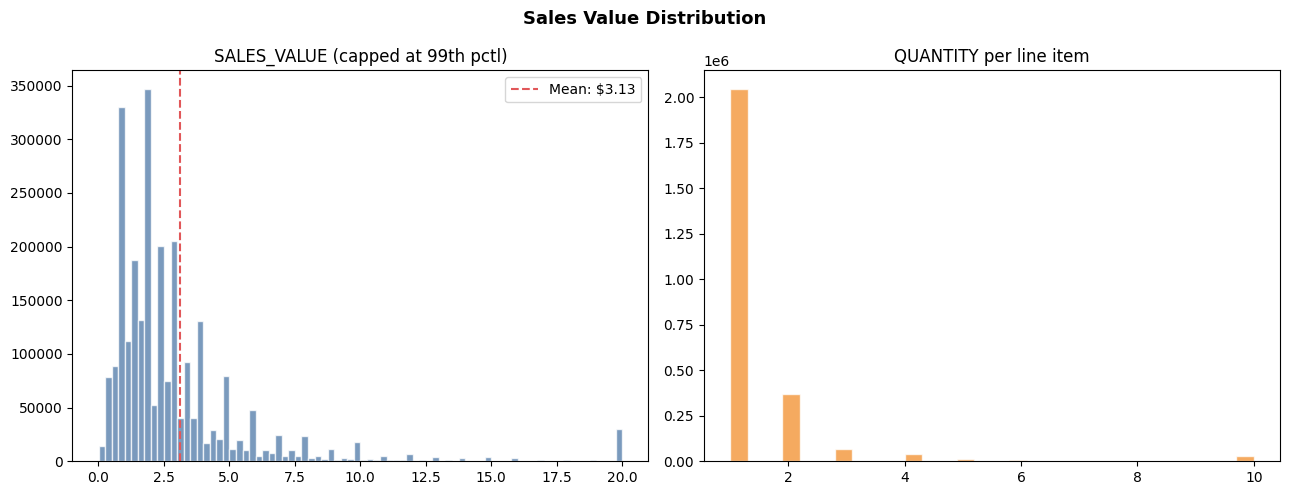

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
fig.suptitle("Sales Value Distribution", fontsize=13, fontweight="bold")

cap = txn["SALES_VALUE"].quantile(0.99)
axes[0].hist(txn["SALES_VALUE"].clip(upper=cap), bins=80, color="#4E79A7", alpha=0.75, edgecolor="white")
axes[0].axvline(txn["SALES_VALUE"].mean(), color="#E15759", ls="--", label=f'Mean: ${txn["SALES_VALUE"].mean():.2f}')
axes[0].set_title("SALES_VALUE (capped at 99th pctl)"); axes[0].legend()

axes[1].hist(txn["QUANTITY"].clip(upper=txn["QUANTITY"].quantile(0.99)), bins=30, color="#F28E2B", alpha=0.75, edgecolor="white")
axes[1].set_title("QUANTITY per line item")

plt.tight_layout(); plt.savefig(REPORTS_DIR/"eda_02_sales_dist.png", dpi=150, bbox_inches="tight")
plt.show()


### 2.3 Top Departments & Categories

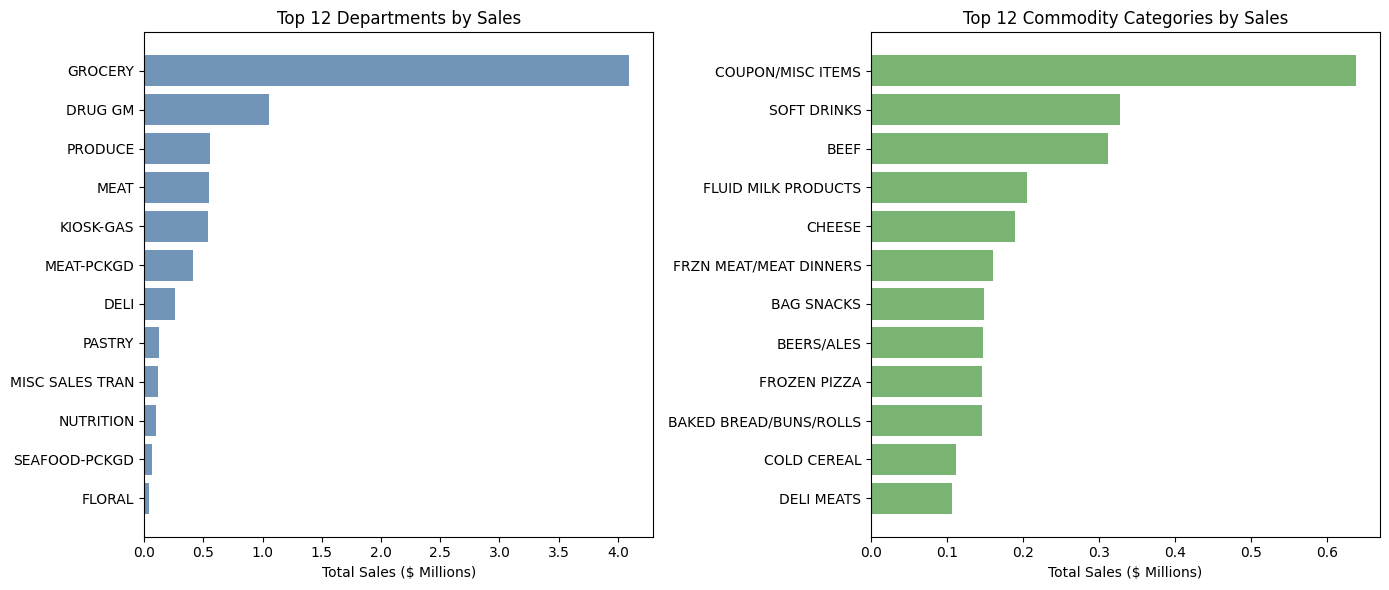

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

top_dept = txn.groupby("DEPARTMENT")["SALES_VALUE"].sum().sort_values(ascending=False).head(12)
axes[0].barh(top_dept.index[::-1], top_dept.values[::-1]/1e6, color="#4E79A7", alpha=0.8)
axes[0].set_xlabel("Total Sales ($ Millions)"); axes[0].set_title("Top 12 Departments by Sales")

top_comm = txn.groupby("COMMODITY_DESC")["SALES_VALUE"].sum().sort_values(ascending=False).head(12)
axes[1].barh(top_comm.index[::-1], top_comm.values[::-1]/1e6, color="#59A14F", alpha=0.8)
axes[1].set_xlabel("Total Sales ($ Millions)"); axes[1].set_title("Top 12 Commodity Categories by Sales")

plt.tight_layout(); plt.savefig(REPORTS_DIR/"eda_03_top_categories.png", dpi=150, bbox_inches="tight")
plt.show()


### 2.4 RFM Feature Distributions

In [7]:
# Build RFM using the existing RFMBuilder (reuse!)
splitter = TimeSplitter(config)
cal_txn, hold_txn = splitter.split(txn)

builder = RFMBuilder(config)
rfm = builder.compute_rfm(cal_txn, analysis_end_week=CAL_END)
print(rfm.shape)
print(rfm.describe().T[["mean","std","min","50%","max"]].round(2))


2026-04-25 20:11:10.528 | INFO     | src.features.time_splitter:split:94 - Splitting transactions at WEEK_NO = 75 ...
2026-04-25 20:11:10.530 | INFO     | src.features.time_splitter:split:97 -   → Data range: Week 1 to Week 102 (102 weeks total)
2026-04-25 20:11:11.193 | INFO     | src.features.time_splitter:split:123 -   ✓ Calibration (Week 1–75): 1,818,011 txns | 2,498 households
2026-04-25 20:11:11.195 | INFO     | src.features.time_splitter:split:127 -   ✓ Holdout     (Week 76–102): 758,777 txns | 2,433 households
2026-04-25 20:11:11.196 | INFO     | src.features.time_splitter:split:131 -   → 2 households appear ONLY in holdout (new customers after calibration)
2026-04-25 20:11:11.197 | INFO     | src.features.time_splitter:split:137 -   → Split ratio: 70.6% calibration / 29.4% holdout
2026-04-25 20:11:11.199 | INFO     | src.features.rfm_builder:compute_rfm:91 - Computing RFM features grouped by 'household_key' ...
2026-04-25 20:11:12.130 | INFO     | src.features.rfm_builder:_val

(2498, 15)
                            mean        std     min        50%         max
household_key         1,249.7800   721.6500  1.0000 1,249.5000  2,500.0000
Recency                   3.6000     9.5100  0.0000     0.0000     70.0000
Frequency                77.8900    86.2800  0.0000    53.0000  1,043.0000
T                        64.9100     5.1500 12.0000    64.0000     74.0000
Gross_Sales           2,256.9600 2,393.3700  3.5500 1,502.0800 23,879.4500
Net_Sales             1,852.7800 2,038.2000  1.8600 1,211.7800 22,536.2400
avg_monetary             25.3700    16.4700  0.0000    21.6500    141.5600
total_baskets            78.8900    86.2800  1.0000    54.0000  1,044.0000
avg_basket_size         690.1400 1,230.0100  1.0000    55.2600 16,322.5000
avg_transaction_value    25.4700    16.4500  1.8600    21.7200    141.5600
distinct_stores           4.6200     2.9800  1.0000     4.0000     24.0000
tenure_weeks             61.3100    10.8600  0.0000    63.0000     74.0000
coupon_usage_r

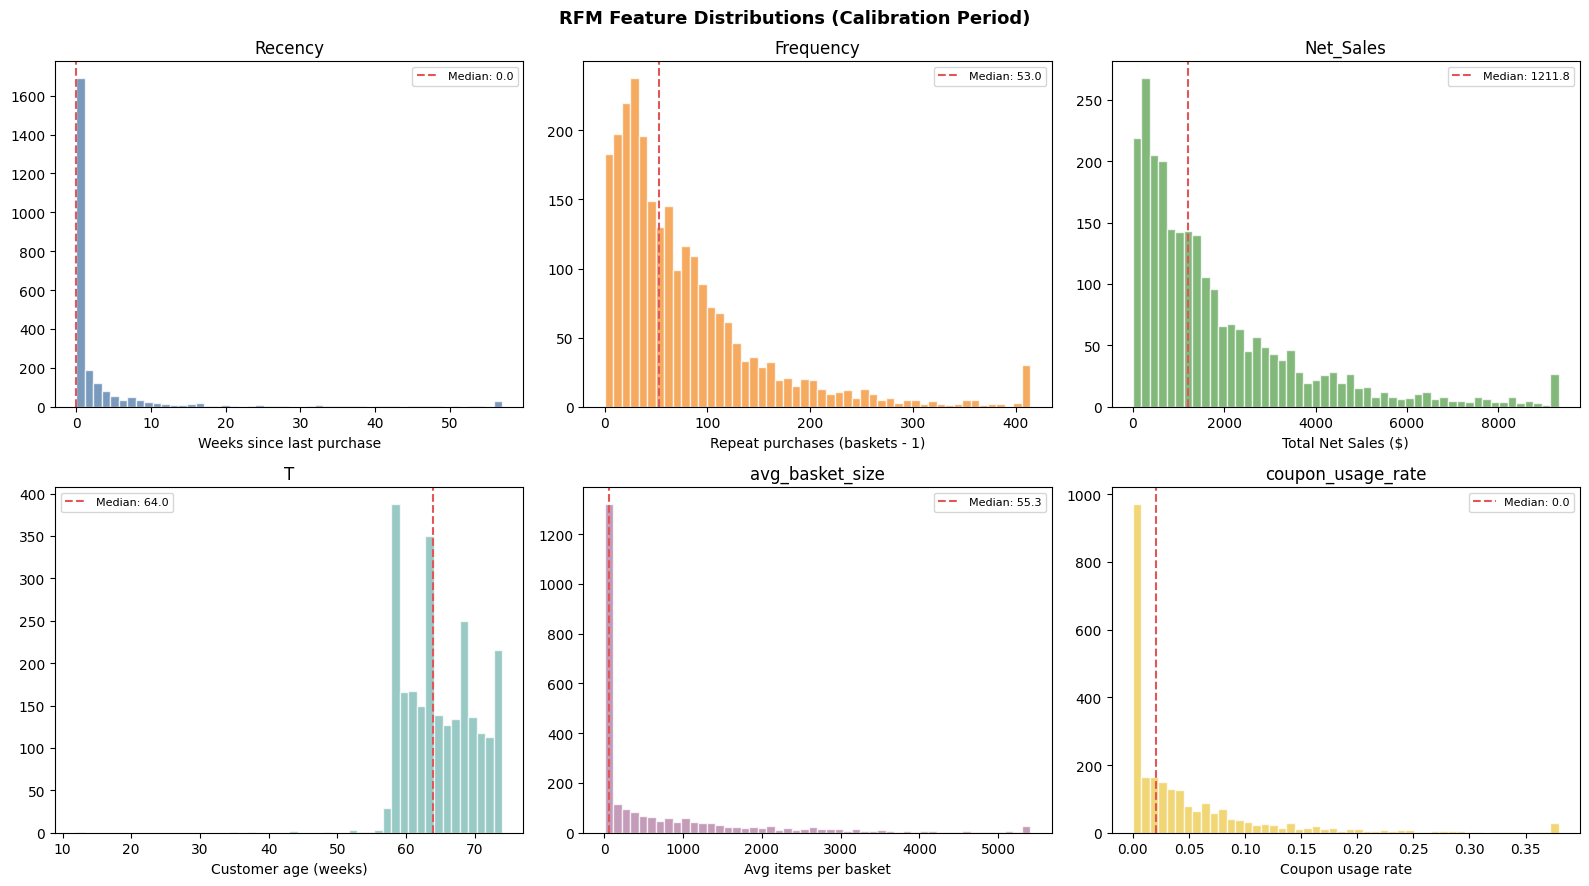

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16,9))
fig.suptitle("RFM Feature Distributions (Calibration Period)", fontsize=13, fontweight="bold")

features = [
    ("Recency",       "Weeks since last purchase",       "#4E79A7"),
    ("Frequency",     "Repeat purchases (baskets - 1)", "#F28E2B"),
    ("Net_Sales",     "Total Net Sales ($)",             "#59A14F"),
    ("T",             "Customer age (weeks)",            "#76B7B2"),
    ("avg_basket_size","Avg items per basket",           "#B07AA1"),
    ("coupon_usage_rate","Coupon usage rate",            "#EDC948"),
]
for idx, (col, xlabel, color) in enumerate(features):
    ax = axes[idx//3, idx%3]
    if col in rfm.columns:
        data = rfm[col].dropna().clip(upper=rfm[col].quantile(0.99))
        ax.hist(data, bins=50, color=color, alpha=0.75, edgecolor="white")
        ax.axvline(rfm[col].median(), color="#E15759", ls="--",
                   label=f"Median: {rfm[col].median():.1f}")
        ax.set_title(col); ax.set_xlabel(xlabel); ax.legend(fontsize=8)

plt.tight_layout(); plt.savefig(REPORTS_DIR/"eda_04_rfm_dist.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Cohort Analysis

**Design**:
- **Cohort key**: `household_key` (one row per household)
- **Cohort group**: 4-week block of the household's *first* purchase (`cohort_group = ceil(first_purchase_week / 4)`)
- **Time granularity**: 4-week periods (~monthly equivalent, since data has no real dates)
- **Cohort index**: number of 4-week periods since cohort's first period
- **Retention metric**: % of cohort households still active in each subsequent period
- **Assumption**: A household is "active" in a period if it made ≥1 purchase in that 4-week block


In [9]:
# ── Step 1: Create 4-week period column ───────────────────────────────────────
txn_coh = txn.copy()
txn_coh["period"] = np.ceil(txn_coh["WEEK_NO"] / 4).astype(int)  # period 1–26

# ── Step 2: Find each household's first purchase period (cohort group) ─────────
cohort_map = (txn_coh.groupby("household_key")["period"].min()
                     .rename("cohort_group").reset_index())

txn_coh = txn_coh.merge(cohort_map, on="household_key", how="left")

# ── Step 3: Unique (household, period) pairs — active households per period ────
active = txn_coh[["household_key","cohort_group","period"]].drop_duplicates()
active["cohort_index"] = active["period"] - active["cohort_group"]

# ── Step 4: Build cohort size table ───────────────────────────────────────────
cohort_sizes = (active[active["cohort_index"] == 0]
                .groupby("cohort_group")["household_key"].nunique()
                .rename("cohort_size"))

# ── Step 5: Count active households per (cohort_group, cohort_index) ──────────
retention_raw = (active.groupby(["cohort_group","cohort_index"])["household_key"]
                       .nunique().reset_index())
retention_raw.columns = ["cohort_group","cohort_index","n_active"]

# ── Step 6: Merge sizes & normalize ───────────────────────────────────────────
retention_raw = retention_raw.merge(cohort_sizes, on="cohort_group")
retention_raw["retention_rate"] = retention_raw["n_active"] / retention_raw["cohort_size"]

# Pivot to matrix
cohort_matrix = retention_raw.pivot(index="cohort_group",
                                    columns="cohort_index",
                                    values="retention_rate")

# ── Validate: cohort_index = 0 must be 100% ──────────────────────────────────
assert (cohort_matrix[0].dropna() == 1.0).all(), "cohort_index=0 not 100%!"
print("✓ cohort_index = 0 is 100% for all cohorts")

print(f"\nCohort matrix shape: {cohort_matrix.shape}")
print(f"Periods: {cohort_matrix.index.min()} – {cohort_matrix.index.max()}")
print("\nFirst 5 rows, first 6 periods:")
print((cohort_matrix.iloc[:5, :6] * 100).round(1).to_string())


✓ cohort_index = 0 is 100% for all cohorts

Cohort matrix shape: (12, 26)
Periods: 1 – 25

First 5 rows, first 6 periods:
cohort_index        0       1       2       3       4       5
cohort_group                                                 
1            100.0000 79.6000 78.5000 81.0000 78.1000 79.6000
2            100.0000 80.8000 80.4000 78.3000 79.1000 78.1000
3            100.0000 81.0000 78.7000 78.4000 77.9000 78.7000
4            100.0000 79.9000 81.5000 79.0000 77.7000 80.3000
5            100.0000 78.0000 76.7000 78.9000 81.2000 80.7000


### 3.1 Cohort Retention Heatmap

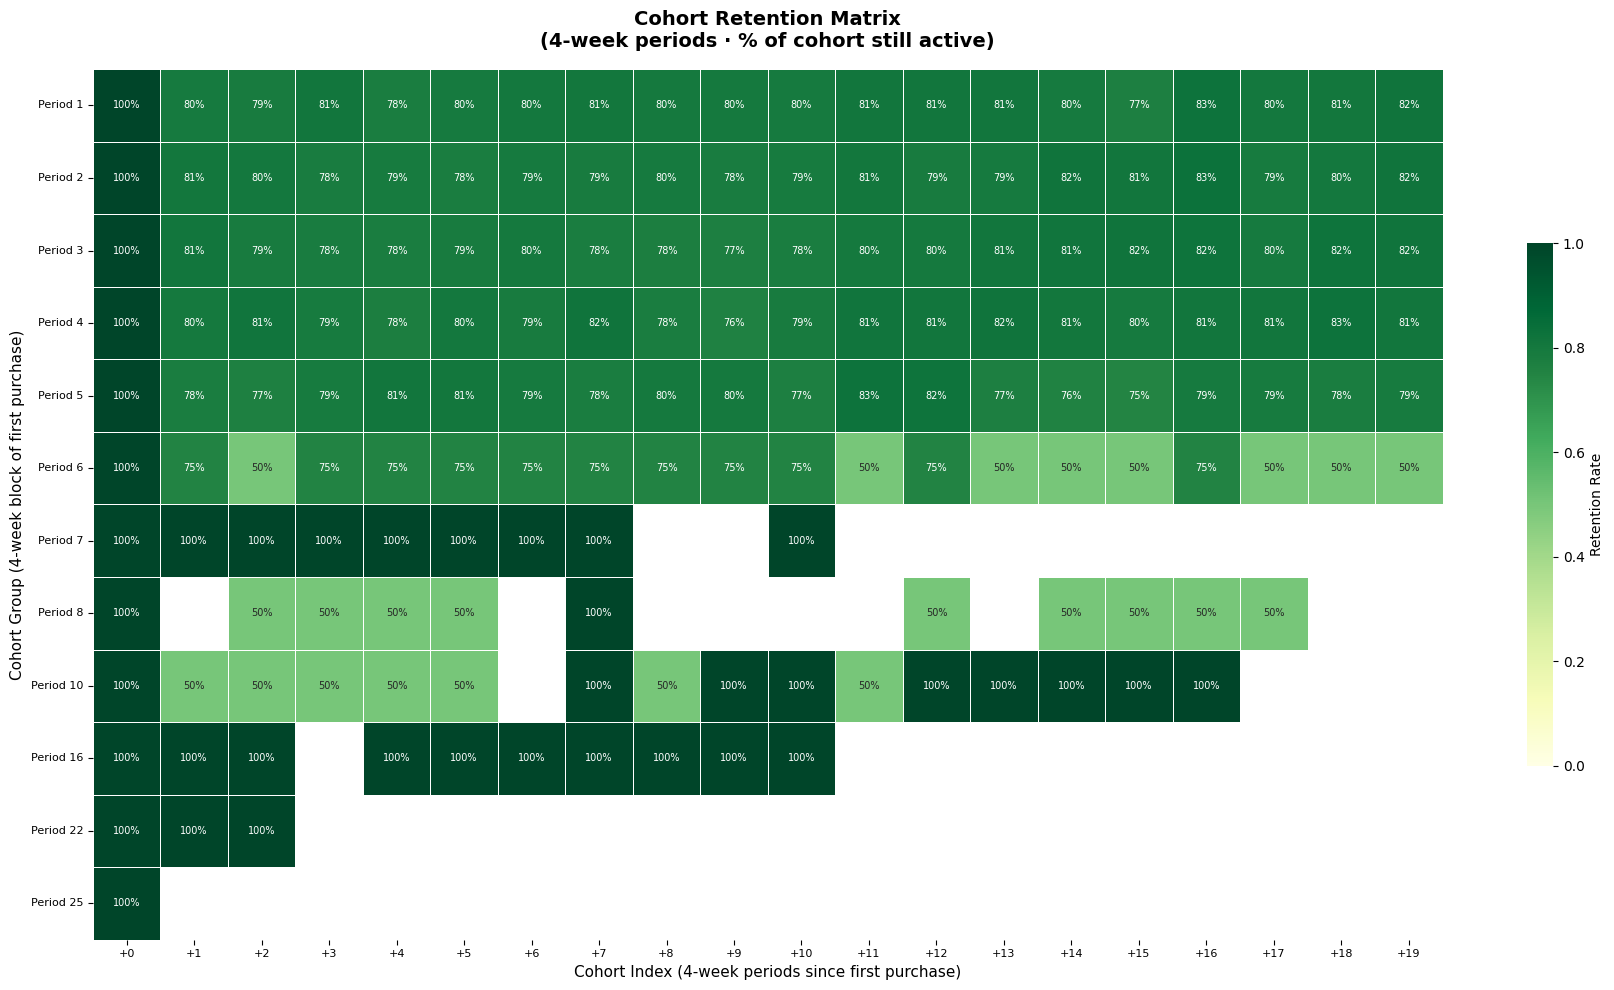

Saved → cohort_retention_heatmap.png


In [10]:
fig, ax = plt.subplots(figsize=(18, 10))

# Only show cohorts with enough data (drop last few periods with heavy NaN)
max_idx = 20  # show up to 20 periods (~80 weeks) for readability
plot_matrix = cohort_matrix.iloc[:, :max_idx]

sns.heatmap(
    plot_matrix,
    annot=True, fmt=".0%",
    cmap="YlGn",
    vmin=0, vmax=1,
    linewidths=0.4,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Retention Rate", "shrink": 0.6},
    annot_kws={"size": 7},
)

ax.set_title("Cohort Retention Matrix\n(4-week periods · % of cohort still active)",
             fontsize=14, fontweight="bold", pad=16)
ax.set_xlabel("Cohort Index (4-week periods since first purchase)", fontsize=11)
ax.set_ylabel("Cohort Group (4-week block of first purchase)", fontsize=11)
ax.set_yticklabels([f"Period {int(t)}" for t in cohort_matrix.index], rotation=0, fontsize=8)
ax.set_xticklabels([f"+{int(t)}" for t in plot_matrix.columns], rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "cohort_retention_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → cohort_retention_heatmap.png")


### 3.2 Average Retention Curve

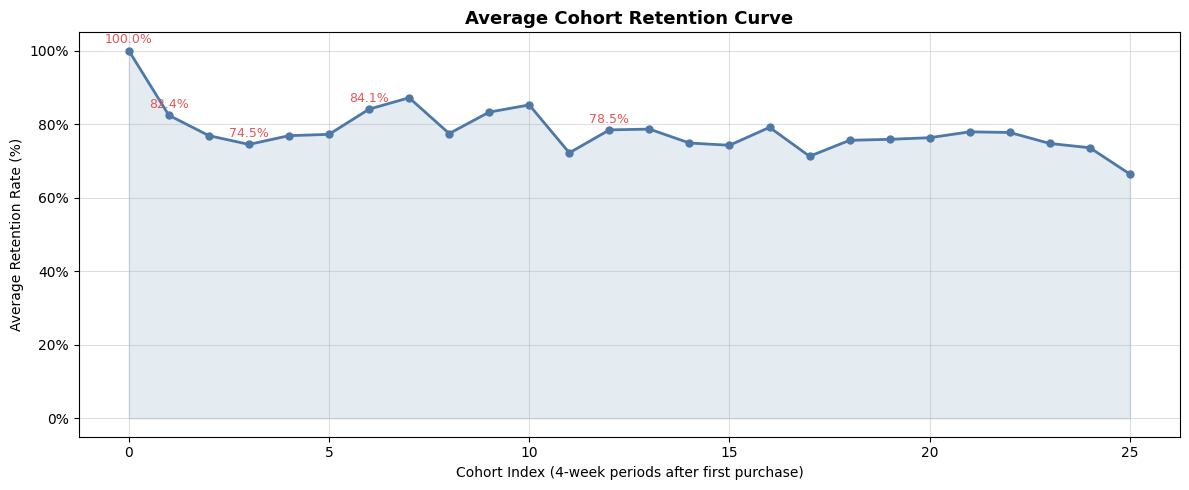


── Retention Summary ─────────────────────────────────────
  Period + 0: 100.0%
  Period + 1: 82.4%
  Period + 2: 76.9%
  Period + 4: 76.9%
  Period + 8: 77.5%
  Period +12: 78.5%
  Period +16: 79.2%


In [11]:
avg_retention = cohort_matrix.mean(axis=0).dropna()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_retention.index, avg_retention.values * 100,
        marker="o", ms=5, color="#4E79A7", lw=2)
ax.fill_between(avg_retention.index, avg_retention.values * 100, alpha=0.15, color="#4E79A7")
ax.set_xlabel("Cohort Index (4-week periods after first purchase)")
ax.set_ylabel("Average Retention Rate (%)")
ax.set_title("Average Cohort Retention Curve", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f%%"))
ax.grid(True, alpha=0.4)

# Annotate key points
for idx in [0, 1, 3, 6, 12]:
    if idx in avg_retention.index:
        y = avg_retention[idx] * 100
        ax.annotate(f"{y:.1f}%", xy=(idx, y), xytext=(idx, y+2),
                    fontsize=9, ha="center", color="#E15759")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "cohort_avg_retention_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Retention Summary ─────────────────────────────────────")
for idx in [0, 1, 2, 4, 8, 12, 16]:
    if idx in avg_retention.index:
        print(f"  Period +{idx:2d}: {avg_retention[idx]*100:.1f}%")


## 4. Market Basket Analysis

**Design**:
- **Transaction unit**: `BASKET_ID` (one unique shopping trip)
- **Item dimension**: `COMMODITY_DESC` (product category level — avoids extreme sparsity from raw PRODUCT_ID)
- **Algorithm**: Apriori via `mlxtend`
- **min_support**: Adaptive — set based on dataset size to ensure ≥30 frequent itemsets
- **Rule filters**: `lift > 1` and `confidence > 0.3`


In [12]:
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    print("mlxtend available ✓")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mlxtend", "-q"])
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    print("mlxtend installed ✓")


mlxtend available ✓


In [13]:
# ── Step 1: Build basket-level transaction list ────────────────────────────────
# Use all transactions (not just calibration) for richer rules
basket_items = (txn.dropna(subset=["COMMODITY_DESC"])
                   .groupby("BASKET_ID")["COMMODITY_DESC"]
                   .apply(list).reset_index())

print(f"Total baskets : {len(basket_items):,}")
print(f"Avg items/basket: {basket_items['COMMODITY_DESC'].apply(len).mean():.1f}")

# ── Step 2: Filter to baskets with ≥ 2 items (meaningful associations) ─────────
basket_items["n_items"] = basket_items["COMMODITY_DESC"].apply(lambda x: len(set(x)))
basket_items = basket_items[basket_items["n_items"] >= 2].copy()
print(f"Baskets with ≥2 distinct categories: {len(basket_items):,}")


Total baskets : 275,516
Avg items/basket: 9.4
Baskets with ≥2 distinct categories: 207,065


In [14]:
# ── Step 3: One-hot encode (Transaction Encoder) ──────────────────────────────
# Use set() to remove duplicates within a basket before encoding
records = basket_items["COMMODITY_DESC"].apply(lambda x: list(set(x))).tolist()

te = TransactionEncoder()
te_array = te.fit_transform(records)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

print(f"Basket matrix: {basket_df.shape[0]:,} rows × {basket_df.shape[1]:,} columns")
print(f"Sparsity: {(~basket_df).values.mean()*100:.1f}% zeros")


Basket matrix: 207,065 rows × 307 columns
Sparsity: 97.1% zeros


In [15]:
# ── Step 4: Adaptive min_support ──────────────────────────────────────────────
# Try progressively lower support until we get at least 30 frequent itemsets
n_baskets = len(basket_df)
target_itemsets = 30

def run_apriori_adaptive(df, start=0.05, floor=0.005, step=0.005):
    support = start
    while support >= floor:
        freq = apriori(df, min_support=support, use_colnames=True, max_len=3)
        if len(freq) >= target_itemsets:
            print(f"✓ min_support = {support:.4f} → {len(freq):,} frequent itemsets")
            return freq, support
        support -= step
        support = round(support, 4)
    # Use floor as last resort
    freq = apriori(df, min_support=floor, use_colnames=True, max_len=3)
    print(f"✓ min_support = {floor:.4f} (floor) → {len(freq):,} frequent itemsets")
    return freq, floor

freq_items, chosen_support = run_apriori_adaptive(basket_df)
print(f"\nFrequent itemsets sample:")
print(freq_items.sort_values("support", ascending=False).head(10).to_string(index=False))


✓ min_support = 0.0500 → 119 frequent itemsets

Frequent itemsets sample:
 support                                      itemsets
  0.3256                         (FLUID MILK PRODUCTS)
  0.3205                                 (SOFT DRINKS)
  0.2876                      (BAKED BREAD/BUNS/ROLLS)
  0.2246                                      (CHEESE)
  0.1990                                  (BAG SNACKS)
  0.1752                                        (BEEF)
  0.1560                              (TROPICAL FRUIT)
  0.1496 (FLUID MILK PRODUCTS, BAKED BREAD/BUNS/ROLLS)
  0.1336                                        (EGGS)
  0.1226            (FLUID MILK PRODUCTS, SOFT DRINKS)


In [16]:
# ── Step 5: Generate association rules ────────────────────────────────────────
rules = association_rules(freq_items, metric="lift", min_threshold=1.0)

# Filter: lift > 1, confidence > 0.3
rules = rules[(rules["lift"] > 1) & (rules["confidence"] > 0.3)].copy()
rules = rules.sort_values("lift", ascending=False).reset_index(drop=True)

print(f"Rules generated (lift>1, confidence>0.3): {len(rules):,}")
print("\nTop 10 rules by lift:")
print(rules[["antecedents","consequents","support","confidence","lift"]].head(10).to_string(index=False))


Rules generated (lift>1, confidence>0.3): 95

Top 10 rules by lift:
                                  antecedents                                   consequents  support  confidence   lift
                                       (EGGS) (FLUID MILK PRODUCTS, BAKED BREAD/BUNS/ROLLS)   0.0504      0.3771 2.5213
(FLUID MILK PRODUCTS, BAKED BREAD/BUNS/ROLLS)                                        (EGGS)   0.0504      0.3367 2.5213
                           (MILK BY-PRODUCTS)                                      (CHEESE)   0.0527      0.5575 2.4819
         (BAKED BREAD/BUNS/ROLLS, BAG SNACKS)                                      (CHEESE)   0.0513      0.5415 2.4104
(FLUID MILK PRODUCTS, BAKED BREAD/BUNS/ROLLS)                              (TROPICAL FRUIT)   0.0527      0.3527 2.2613
                             (TROPICAL FRUIT) (FLUID MILK PRODUCTS, BAKED BREAD/BUNS/ROLLS)   0.0527      0.3382 2.2613
                  (FLUID MILK PRODUCTS, BEEF)                      (BAKED BREAD/BUNS/ROLLS) 

### 4.1 Rules Visualization

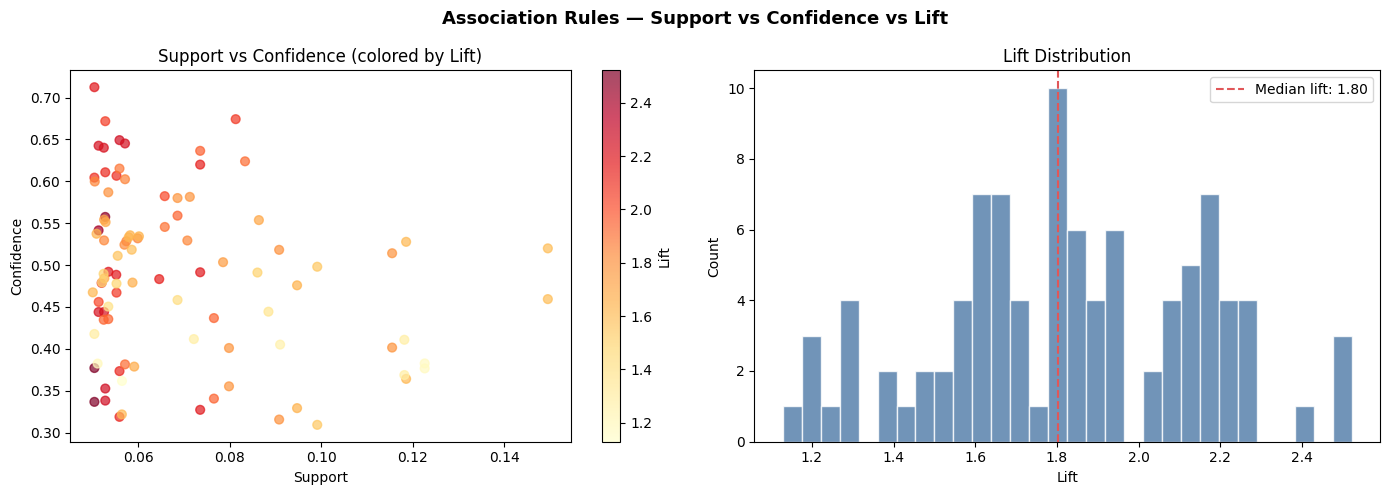

Saved → mba_rules_scatter.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Association Rules — Support vs Confidence vs Lift", fontsize=13, fontweight="bold")

sc = axes[0].scatter(rules["support"], rules["confidence"],
                     c=rules["lift"], cmap="YlOrRd", s=40, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label="Lift")
axes[0].set_xlabel("Support"); axes[0].set_ylabel("Confidence")
axes[0].set_title("Support vs Confidence (colored by Lift)")

axes[1].hist(rules["lift"], bins=30, color="#4E79A7", alpha=0.8, edgecolor="white")
axes[1].axvline(rules["lift"].median(), color="#E15759", ls="--",
                label=f"Median lift: {rules['lift'].median():.2f}")
axes[1].set_xlabel("Lift"); axes[1].set_ylabel("Count")
axes[1].set_title("Lift Distribution"); axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / "mba_rules_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → mba_rules_scatter.png")


### 4.2 Top Rules Visualization

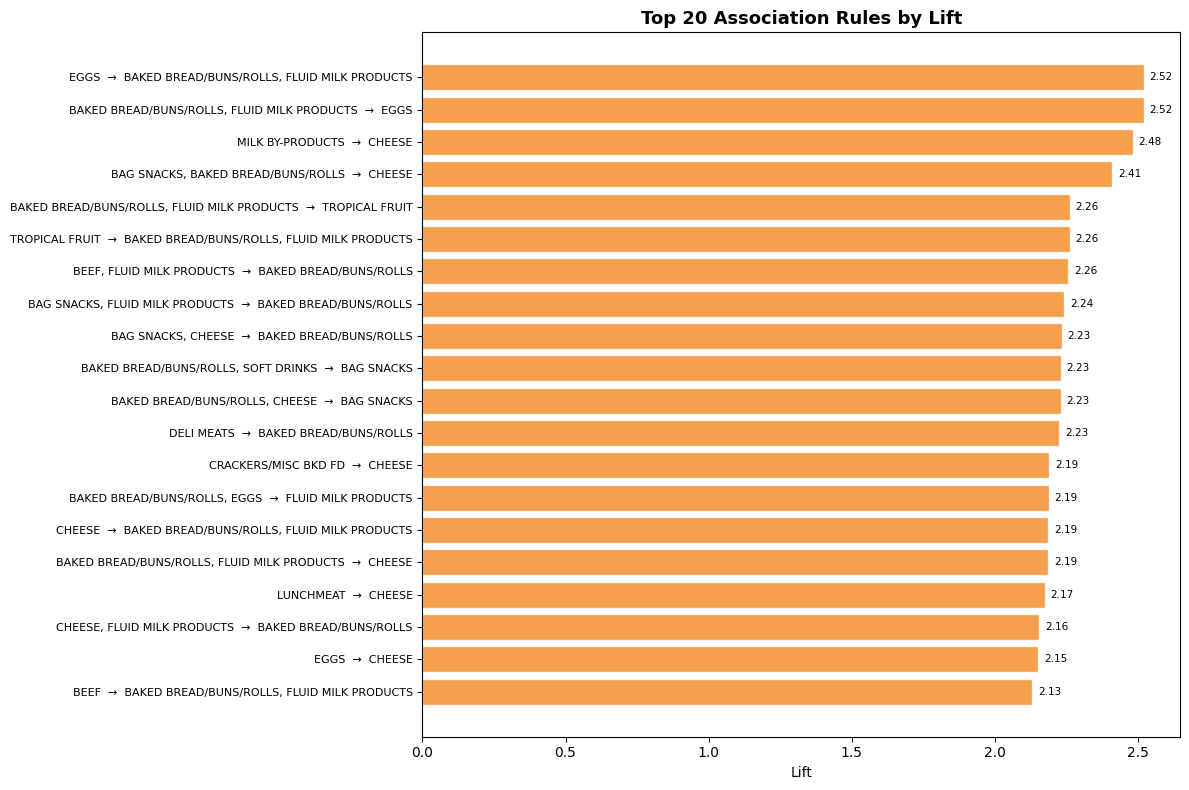

In [18]:
top20 = rules.head(20).copy()
top20["rule"] = (top20["antecedents"].apply(lambda x: ", ".join(sorted(x)))
                 + "  →  "
                 + top20["consequents"].apply(lambda x: ", ".join(sorted(x))))

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(top20)), top20["lift"].values, color="#F28E2B", alpha=0.85, edgecolor="white")
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20["rule"], fontsize=8)
ax.set_xlabel("Lift"); ax.set_title("Top 20 Association Rules by Lift", fontsize=13, fontweight="bold")
ax.invert_yaxis()
for bar, val in zip(bars, top20["lift"].values):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=7.5)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "mba_top20_rules.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Export Results

In [19]:
# ── Format rules for export ───────────────────────────────────────────────────
export_rules = rules.copy()
export_rules["antecedents"] = export_rules["antecedents"].apply(lambda x: ", ".join(sorted(x)))
export_rules["consequents"] = export_rules["consequents"].apply(lambda x: ", ".join(sorted(x)))
export_rules = export_rules[["antecedents","consequents","support","confidence","lift",
                              "leverage","conviction"]].copy()
export_rules[["support","confidence","lift","leverage","conviction"]] =     export_rules[["support","confidence","lift","leverage","conviction"]].round(6)

# Save to project root (sibling of notebooks/)
output_path = PROJECT_ROOT / "market_basket_rules.csv"
export_rules.to_csv(output_path, index=False)

print(f"✓ Saved: {output_path}")
print(f"  Rows  : {len(export_rules):,}")
print(f"\nSample output:")
print(export_rules.head(10).to_string(index=False))


✓ Saved: D:\hoc ki 6\thay long\data_driven_marketing_project\market_basket_rules.csv
  Rows  : 95

Sample output:
                                antecedents                                 consequents  support  confidence   lift  leverage  conviction
                                       EGGS BAKED BREAD/BUNS/ROLLS, FLUID MILK PRODUCTS   0.0504      0.3771 2.5213    0.0304      1.3653
BAKED BREAD/BUNS/ROLLS, FLUID MILK PRODUCTS                                        EGGS   0.0504      0.3367 2.5213    0.0304      1.3063
                           MILK BY-PRODUCTS                                      CHEESE   0.0527      0.5575 2.4819    0.0315      1.7524
         BAG SNACKS, BAKED BREAD/BUNS/ROLLS                                      CHEESE   0.0513      0.5415 2.4104    0.0300      1.6910
BAKED BREAD/BUNS/ROLLS, FLUID MILK PRODUCTS                              TROPICAL FRUIT   0.0527      0.3527 2.2613    0.0294      1.3039
                             TROPICAL FRUIT BAKED BREAD/BU

In [20]:
print("\n══ NOTEBOOK COMPLETE ══════════════════════════════════════")
print(f"  EDA plots      → {REPORTS_DIR}")
print(f"  MBA rules      → market_basket_rules.csv")
print(f"  Cohort heatmap → reports/figures/cohort_retention_heatmap.png")
print(f"  Total rules    : {len(export_rules):,}")
print(f"  Cohort matrix  : {cohort_matrix.shape} (cohort_groups × periods)")
print("═══════════════════════════════════════════════════════════")



══ NOTEBOOK COMPLETE ══════════════════════════════════════
  EDA plots      → D:\hoc ki 6\thay long\data_driven_marketing_project\reports\figures
  MBA rules      → market_basket_rules.csv
  Cohort heatmap → reports/figures/cohort_retention_heatmap.png
  Total rules    : 95
  Cohort matrix  : (12, 26) (cohort_groups × periods)
═══════════════════════════════════════════════════════════
